> **Course copy (ME 5475, Fall 2026).** Min Lin's parametric notebook (CAMML lab), shared with credit. Outputs are cleared and contact details removed; the code is unchanged. It uses DeepXDE's TensorFlow backend and soft boundary conditions, with E and ν as extra network inputs. The course's PyTorch port is `module_3/examples/plate_with_hole_parametric.py` (L16). Deliberate differences: this notebook is plane stress (C11 = E/(1-nu^2), C12 = E*nu/(1-nu^2)), trains over E in [1, 3] and nu in [0.25, 0.35] with Adam 50 000 then L-BFGS, and keeps all ten conditions soft; the port is plane strain, trains over E in [0.5, 2] and nu in [0.2, 0.4] with Adam 100 000 then L-BFGS, and builds the three displacement conditions in (L15). The port's measured results are in `module_3/readings/measured_results.md` §9.

# Solve Solid Mechanics Problem using Physics-Informed Neural Networks


## Authors
+ Min Lin
     + Graduate Research Assistant 
     + [Computations for Advanced Materials and Manufacturing Laboratory](https://www.uwyo.edu/mechanical/faculty-staff/faculty/xiang-zhang/camml.html)
     + Mechanical Engineering, University of Wyoming
     
     
+ Xiang Zhang
     + Assistant Professor
     + [Computations for Advanced Materials and Manufacturing Laboratory](https://www.uwyo.edu/mechanical/faculty-staff/faculty/xiang-zhang/camml.html)
     + Mechanical Engineering, University of Wyoming


## Objectives


+ Learn how to solve PDEs with neural networks.
+ Learn how we can use neural networks to solve a 2D hole problem with various material properties ($E$ and $\nu$) from solid mechanics.


## DeepXDE Library
+ [DeepXDE](https://github.com/lululxvi/deepxde).


## References

+ [Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations](https://www.sciencedirect.com/science/article/pii/S0021999118307125)
+ [DeepXDE: A deep learning library for solving differential equations](https://arxiv.org/pdf/1907.04502.pdf)
+ [A physics-informed deep learning framework for inversion and surrogate modeling in solid mechanics](https://www.sciencedirect.com/science/article/pii/S0045782521000773)



In [ ]:
## let's import the relevant libraries
import deepxde as dde
import numpy as np
from deepxde.backend import tf
import matplotlib.pyplot as plt

## Example: 

Consider an rectangular plate with a circular hole. Assume that the circular hole has a radius of 0.1 and is centered at (0, 0). Moreover, the plate’s thickness and the material’s elasticity are assumed to be 1 with appropriate units. Uniaxial displacement loading $\bar{u}_{1}=1$ is applied in x-direction on both ends of the plate.

The problem can be solved by considering a quarter of the plate and applying Dirichlet boundary conditions according to symmetry.

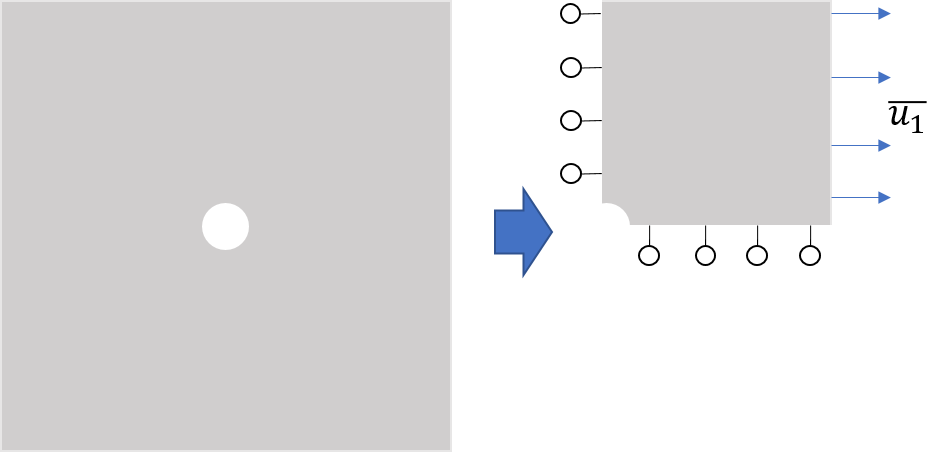

The pde of 2D linear elasticity
$$
\begin{aligned}
&\sigma_{i j, j}+f_{i}=0 \\
&\sigma_{i j}=\lambda \delta_{i j} \varepsilon_{k k}+2 \mu \varepsilon_{i j} \\
&\varepsilon_{i j}=\frac{1}{2}\left(u_{i, j}+u_{j, i}\right)
\end{aligned}
$$

with $x_{1}, x_{2} \in [0,1]^{2}$, $f_{i}=0$ (no body force). In this example, $E$ and $\nu$ are changeable.

We consider the boundary conditions as:
$$u_{1}(0,x_{2})=0$$ 
$$u_{2}(x_{2},0)=0$$
$$u_{1}(1,x_{2})=1$$

In [ ]:
# Define pde of lienar elasticity
def pde(x, u):
    # coordinate variable
    x1, x2 = x[:, 0:1], x[:, 1:2]
    
    # define material properties of plate
    E, nu = x[:, 2:3], x[:, 3:4]
    
    # displacements and stress variavles
    u1, u2, S11, S22, S12 = u[:, 0:1], u[:, 1:2], u[:, 2:3], u[:, 3:4], u[:, 4:5]
    
    # define strain from displacements using auto differentiation
    E11 = dde.grad.jacobian(u, x, i=0, j=0)
    E22 = dde.grad.jacobian(u, x, i=1, j=1)
    E12 = 0.5 * (dde.grad.jacobian(u, x, i=0, j=1) + dde.grad.jacobian(u, x, i=1, j=0))
    
    # constitutive equations
    eq_1 = dde.grad.jacobian(S11, x, j=0) + dde.grad.jacobian(S12, x, j=1)
    eq_2 = dde.grad.jacobian(S12, x, j=0) + dde.grad.jacobian(S22, x, j=1)
    
    # stiffness matrix from E and mu
    C11 = E/(1-nu*nu)
    C12 = E*nu/(1-nu*nu)
    C21 = C12
    C22 = C11
    C33 = E/(1+nu)
    
    # relationship bewteen stress and strain
    eq_3 = S11 - C11*E11 - C12*E22
    eq_4 = S22 - C21*E11 - C22*E22
    eq_5 = S12 - C33*E12
    
    return [eq_1, eq_2, eq_3, eq_4, eq_5]   

In [ ]:
# define radius of hole
rhole = 0.1
# define boudnaries
def boundary_left(x, on_boundary):
    return np.isclose(x[0], 0)

def boundary_right(x, on_boundary):
    return np.isclose(x[0], 1)

def boundary_bottom(x, on_boundary):
    return np.isclose(x[1], 0)

def boundary_top(x, on_boundary):
    return np.isclose(x[1], 1)

def boundary_hole(x, on_boundary):
    return np.isclose(x[0]**2 + x[1]**2 - rhole**2, 0)

# define traction boundary for hole in both x and y direcions
def bc_hole_t1(x, u, X):
    r = rhole
    x1, x2 = x[:, 0:1], x[:, 1:2]
    u1, u2, S11, S22, S12 = u[:, 0:1], u[:, 1:2], u[:, 2:3], u[:, 3:4], u[:, 4:5]
    n1 = -x1 / r
    n2 = -x2 / r
    t1 = S11*n1 + S12*n2
    t2 = S12*n1 + S22*n2
    return t1

def bc_hole_t2(x, u, X):
    r = rhole
    x1, x2 = x[:, 0:1], x[:, 1:2]
    u1, u2, S11, S22, S12 = u[:, 0:1], u[:, 1:2], u[:, 2:3], u[:, 3:4], u[:, 4:5]
    n1 = -x1 / r
    n2 = -x2 / r
    t1 = S11*n1 + S12*n2
    t2 = S12*n1 + S22*n2
    return t2

In [ ]:
# In this example, we can take advantage of builtin function in DeepXDE to get the training points for x1 and x2, 
# and then add E and mu to the array
# First define 2D geometry and get data points
rect = dde.geometry.Rectangle(xmin=[0, 0], xmax=[1, 1])
hole = dde.geometry.Disk(center=[0, 0], radius=rhole)
geom = rect - (rect & hole)
data1 = dde.data.PDE(geom, pde, [],num_domain=15000, num_boundary=3000, num_test=0)

# Then define 4D geometry with E and nu added to the end of data1 training points
X = np.array(data1.train_x_all)
X = np.pad(X, ((0,0), (0, 2)), mode='constant', constant_values=0)
X[:, 2] = np.random.uniform(low=1, high=3, size=(X.shape[0],)) # E: 1 ~ 3
X[:, 3] = np.random.uniform(low=0.25, high=0.35, size=(X.shape[0]),) # nu: 0.25 ~ 0.35
geom = dde.geometry.Hypercube(xmin=[0, 0, 1, 0.25], xmax=[1, 1, 3, 0.35])


# Define Dirichlet BC and Neumann BC
BC_left_1 = dde.DirichletBC(geom, lambda x: 0, boundary_left, component=0)
BC_left_2 = dde.DirichletBC(geom, lambda x: 0, boundary_left, component=4)

BC_bot_1 = dde.DirichletBC(geom, lambda x: 0, boundary_bottom, component=1)
BC_bot_2 = dde.DirichletBC(geom, lambda x: 0, boundary_bottom, component=4)

BC_top_1 = dde.DirichletBC(geom, lambda x: 0, boundary_top, component=3)
BC_top_2 = dde.DirichletBC(geom, lambda x: 0, boundary_top, component=4)

BC_right_1 = dde.DirichletBC(geom, lambda x: 1.0, boundary_right, component=0) #disp load
BC_right_2 = dde.DirichletBC(geom, lambda x: 0, boundary_right, component=4)

# define Neumann BC for hole
BC_hole_1 = dde.OperatorBC(geom, bc_hole_t1, boundary_hole)
BC_hole_2 = dde.OperatorBC(geom, bc_hole_t2, boundary_hole)

In [ ]:
# Define the training data (anchor points) and loss function.
data = dde.data.PDE(
    geom, pde, 
    [BC_left_1, BC_left_2, BC_right_1, BC_right_2, 
      BC_bot_1, BC_bot_2, BC_top_1, BC_top_2, BC_hole_1, BC_hole_2],
    num_domain=0, num_boundary=0, anchors=X, num_test=2000)

In [ ]:
# Define structure of neural networks and activation functions. Here we have 4 inputs
layer_size = [4] + [50] * 6 + [5]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.maps.FNN(layer_size, activation, initializer)

In [ ]:
# Train the model
model = dde.Model(data, net)
# optiizer is adam and L-BFGS, and default loss function is MSE (mean squared error)
model.compile("adam", lr=1e-3)
model.train(epochs=50000)
model.compile("L-BFGS")
losshistory, train_state = model.train()

In [ ]:
# Save and plot loss history
dde.saveplot(losshistory, train_state, issave=True, isplot=True)

In [ ]:
# Plot the final results
xx, yy = np.meshgrid(np.linspace(0,1,101), np.linspace(0,1,101))
xxx = xx[xx**2 + yy**2 >= 0.1**2]
yyy = yy[xx**2 + yy**2 >= 0.1**2]
xx = xxx 
yy = yyy
X = np.vstack((np.ravel(xx), np.ravel(yy))).T
X = np.pad(X, ((0,0), (0, 2)), mode='constant', constant_values=0)
X[:, 2] = 1 # E: 1 ~ 3
X[:, 3] = 0.3 # nu: 0.25 ~ 0.35
d_test = model.predict(X)

fig,ax = plt.subplots(1,5,figsize=(15,3))
plot1 = ax[0].scatter(xx, yy, c=d_test[:, 0], alpha=0.7, edgecolors='none',
                          marker='s', cmap='rainbow')
plot2 = ax[1].scatter(xx, yy, c=d_test[:, 1], alpha=0.7, edgecolors='none',
                          marker='s', cmap='rainbow')
plot3 = ax[2].scatter(xx, yy, c=d_test[:, 2], alpha=0.7, edgecolors='none',
                          marker='s', cmap='rainbow')
plot4 = ax[3].scatter(xx, yy, c=d_test[:, 3], alpha=0.7, edgecolors='none',
                          marker='s', cmap='rainbow')
plot5 = ax[4].scatter(xx, yy, c=d_test[:, 4], alpha=0.7, edgecolors='none',
                          marker='s', cmap='rainbow')
ax[0].axis('square')
ax[1].axis('square')
ax[2].axis('square')
ax[3].axis('square')
ax[4].axis('square')
ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[3].axis('off')
ax[4].axis('off')
cbar0 = plt.colorbar(plot1, ax=ax[0], fraction=0.046, pad=0.01, aspect=20)
cbar0.ax.set_title(r'$u_{1}$', x=0.7, y=1.03)
cbar1 = plt.colorbar(plot2, ax=ax[1], fraction=0.046, pad=0.01, aspect=20)
cbar1.ax.set_title(r'$u_{2}$', x=0.7, y=1.03)
cbar2 = plt.colorbar(plot3, ax=ax[2], fraction=0.046, pad=0.01, aspect=20)
cbar2.ax.set_title(r'$\sigma_{11}$', x=0.7, y=1.03)
cbar3 = plt.colorbar(plot4, ax=ax[3], fraction=0.046, pad=0.01, aspect=20)
cbar3.ax.set_title(r'$\sigma_{22}$', x=0.7, y=1.03)
cbar4 = plt.colorbar(plot5, ax=ax[4], fraction=0.046, pad=0.01, aspect=20)
cbar4.ax.set_title(r'$\sigma_{12}$', x=0.7, y=1.03)
plt.show()

In [ ]:
# Plot the final results
xx, yy = np.meshgrid(np.linspace(0,1,101), np.linspace(0,1,101))
xxx = xx[xx**2 + yy**2 >= 0.1**2]
yyy = yy[xx**2 + yy**2 >= 0.1**2]
xx = xxx 
yy = yyy
X = np.vstack((np.ravel(xx), np.ravel(yy))).T
X = np.pad(X, ((0,0), (0, 2)), mode='constant', constant_values=0)
X[:, 2] = 2 # E: 1 ~ 3
X[:, 3] = 0.28 # nu: 0.25 ~ 0.35
d_test = model.predict(X)

fig,ax = plt.subplots(1,5,figsize=(15,3))
plot1 = ax[0].scatter(xx, yy, c=d_test[:, 0], alpha=0.7, edgecolors='none',
                          marker='s', cmap='rainbow')
plot2 = ax[1].scatter(xx, yy, c=d_test[:, 1], alpha=0.7, edgecolors='none',
                          marker='s', cmap='rainbow')
plot3 = ax[2].scatter(xx, yy, c=d_test[:, 2], alpha=0.7, edgecolors='none',
                          marker='s', cmap='rainbow')
plot4 = ax[3].scatter(xx, yy, c=d_test[:, 3], alpha=0.7, edgecolors='none',
                          marker='s', cmap='rainbow')
plot5 = ax[4].scatter(xx, yy, c=d_test[:, 4], alpha=0.7, edgecolors='none',
                          marker='s', cmap='rainbow')
ax[0].axis('square')
ax[1].axis('square')
ax[2].axis('square')
ax[3].axis('square')
ax[4].axis('square')
ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[3].axis('off')
ax[4].axis('off')
cbar0 = plt.colorbar(plot1, ax=ax[0], fraction=0.046, pad=0.01, aspect=20)
cbar0.ax.set_title(r'$u_{1}$', x=0.7, y=1.03)
cbar1 = plt.colorbar(plot2, ax=ax[1], fraction=0.046, pad=0.01, aspect=20)
cbar1.ax.set_title(r'$u_{2}$', x=0.7, y=1.03)
cbar2 = plt.colorbar(plot3, ax=ax[2], fraction=0.046, pad=0.01, aspect=20)
cbar2.ax.set_title(r'$\sigma_{11}$', x=0.7, y=1.03)
cbar3 = plt.colorbar(plot4, ax=ax[3], fraction=0.046, pad=0.01, aspect=20)
cbar3.ax.set_title(r'$\sigma_{22}$', x=0.7, y=1.03)
cbar4 = plt.colorbar(plot5, ax=ax[4], fraction=0.046, pad=0.01, aspect=20)
cbar4.ax.set_title(r'$\sigma_{12}$', x=0.7, y=1.03)
plt.show()

In [ ]:
# Plot the final results
xx, yy = np.meshgrid(np.linspace(0,1,101), np.linspace(0,1,101))
xxx = xx[xx**2 + yy**2 >= 0.1**2]
yyy = yy[xx**2 + yy**2 >= 0.1**2]
xx = xxx 
yy = yyy
X = np.vstack((np.ravel(xx), np.ravel(yy))).T
X = np.pad(X, ((0,0), (0, 2)), mode='constant', constant_values=0)
X[:, 2] = 3 # E: 1 ~ 3
X[:, 3] = 0.33 # nu: 0.25 ~ 0.35
d_test = model.predict(X)

fig,ax = plt.subplots(1,5,figsize=(15,3))
plot1 = ax[0].scatter(xx, yy, c=d_test[:, 0], alpha=0.7, edgecolors='none',
                          marker='s', cmap='rainbow')
plot2 = ax[1].scatter(xx, yy, c=d_test[:, 1], alpha=0.7, edgecolors='none',
                          marker='s', cmap='rainbow')
plot3 = ax[2].scatter(xx, yy, c=d_test[:, 2], alpha=0.7, edgecolors='none',
                          marker='s', cmap='rainbow')
plot4 = ax[3].scatter(xx, yy, c=d_test[:, 3], alpha=0.7, edgecolors='none',
                          marker='s', cmap='rainbow')
plot5 = ax[4].scatter(xx, yy, c=d_test[:, 4], alpha=0.7, edgecolors='none',
                          marker='s', cmap='rainbow')
ax[0].axis('square')
ax[1].axis('square')
ax[2].axis('square')
ax[3].axis('square')
ax[4].axis('square')
ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[3].axis('off')
ax[4].axis('off')
cbar0 = plt.colorbar(plot1, ax=ax[0], fraction=0.046, pad=0.01, aspect=20)
cbar0.ax.set_title(r'$u_{1}$', x=0.7, y=1.03)
cbar1 = plt.colorbar(plot2, ax=ax[1], fraction=0.046, pad=0.01, aspect=20)
cbar1.ax.set_title(r'$u_{2}$', x=0.7, y=1.03)
cbar2 = plt.colorbar(plot3, ax=ax[2], fraction=0.046, pad=0.01, aspect=20)
cbar2.ax.set_title(r'$\sigma_{11}$', x=0.7, y=1.03)
cbar3 = plt.colorbar(plot4, ax=ax[3], fraction=0.046, pad=0.01, aspect=20)
cbar3.ax.set_title(r'$\sigma_{22}$', x=0.7, y=1.03)
cbar4 = plt.colorbar(plot5, ax=ax[4], fraction=0.046, pad=0.01, aspect=20)
cbar4.ax.set_title(r'$\sigma_{12}$', x=0.7, y=1.03)
plt.show()